# Project 3 Computer Vision
## Part 1: Cat detection

<div dir="rtl" align="right" style="
    max-width: 900px;
    margin: auto;
    padding: 30px 40px;
    line-height: 1.9;
">

### یاسمین اخوین        شماره دانشجویی: 810100079
### سروناز صالحی        شماره دانشجویی: 810101462

---

## Part 1: Data Production

<div dir="rtl" align="right" style="
    max-width: 900px;
    margin: auto;
    padding: 30px 40px;
    line-height: 1.9;
">

### بارگذاری تصاویر گربه‌ها
تصاویر `cat1.webp` و `cat2.jpeg` را بارگذاری کرده و برای نمایش صحیح در Matplotlib، فضای رنگی آن‌ها را از BGR به RGB تبدیل می‌کنیم.

</div>


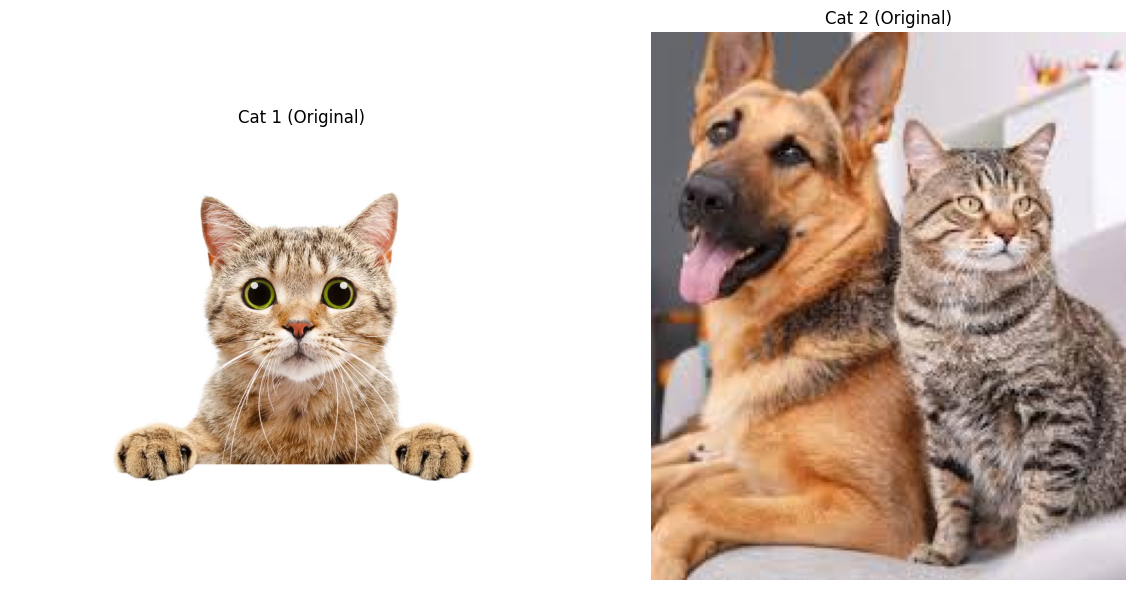

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the images using OpenCV
cat1_bgr = cv2.imread('cat1.webp')
cat2_bgr = cv2.imread('cat2.jpeg')

# Check if images are loaded successfully
if cat1_bgr is None or cat2_bgr is None:
    raise FileNotFoundError("Could not open or find the images. Please check the file paths.")

# Convert BGR to RGB for correct display with matplotlib
cat1_rgb = cv2.cvtColor(cat1_bgr, cv2.COLOR_BGR2RGB)
cat2_rgb = cv2.cvtColor(cat2_bgr, cv2.COLOR_BGR2RGB)

# Plot both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cat1_rgb)
axes[0].set_title("Cat 1 (Original)")
axes[0].axis('off')

axes[1].imshow(cat2_rgb)
axes[1].set_title("Cat 2 (Original)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="
    max-width: 900px;
    margin: auto;
    padding: 30px 40px;
    line-height: 1.9;
">

### تعریف تابع اصلی تشخیص چهره گربه با پارامترهای مشخص‌شده
در این سلول، تابعی پیاده‌سازی می‌کنیم که تصویر ورودی، مسیر فایل مدل Cascade، و وضعیت اعمال فیلتر محوکننده (Blur) را دریافت می‌کند. این تابع طبق خواسته‌ی صورت پروژه، چهره‌ها را با پارامترهای دقیق `scaleFactor=1.1`، `minNeighbors=5` و `minSize=(50, 50)` شناسایی کرده، دور آن‌ها مستطیل سبز رنگ رسم می‌کند و متن 'Cat' را در بالای کادر می‌نویسد.

In [3]:
def detect_cat_faces(image_bgr, cascade_path, apply_blur=False):
    """
    Detects cat faces in an image using a Haar Cascade classifier with specific parameters.
    
    Parameters:
        image_bgr (numpy.ndarray): The input image in BGR format.
        cascade_path (str): Path to the Haar Cascade XML file.
        apply_blur (bool): If True, applies Gaussian Blur to smooth the image before detection.
        
    Returns:
        numpy.ndarray: The image with bounding boxes and text rendered in RGB format.
        int: The number of detected faces.
    """
    # Create a copy to avoid modifying the original image
    annotated_image = image_bgr.copy()
    
    # Convert image to grayscale as Haar Cascades require grayscale inputs
    gray = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2GRAY)
    
    # Optionally apply Gaussian Blur to smooth noise and potentially improve accuracy
    if apply_blur:
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        
    # Load the Haar Cascade classifier
    cascade = cv2.CascadeClassifier(cascade_path)
    if cascade.empty():
        raise IOError(f"Failed to load cascade classifier from path: {cascade_path}")
        
    # Detect cat faces using the exact parameters specified in the project description
    faces = cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )
    
    # Draw bounding boxes and text for each detected face
    for (x, y, w, h) in faces:
        # Draw a green rectangle around the face
        cv2.rectangle(annotated_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Write 'Cat' text just above the bounding box
        cv2.putText(
            annotated_image, 
            "Cat", 
            (x, y - 10), 
            cv2.FONT_HERSHEY_SIMPLEX, 
            0.7, 
            (0, 255, 0), 
            2, 
            cv2.LINE_AA
        )
        
    # Convert the annotated image to RGB for matplotlib plotting
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    
    return annotated_image_rgb, len(faces)

<div dir="rtl" align="right" style="
    max-width: 900px;
    margin: auto;
    padding: 30px 40px;
    line-height: 1.9;
">

### اجرای تست‌های اولیه روی تصاویر ورودی
حالا تابع تعریف‌شده را با هر دو مدل `haarcascade_frontalcatface.xml` و `haarcascade_frontalcatface_extended.xml` روی هر دو تصویر اصلی بدون اعمال بلور تست می‌کنیم تا رفتار اولیه و تفاوت دو مدل را بسنجیم.

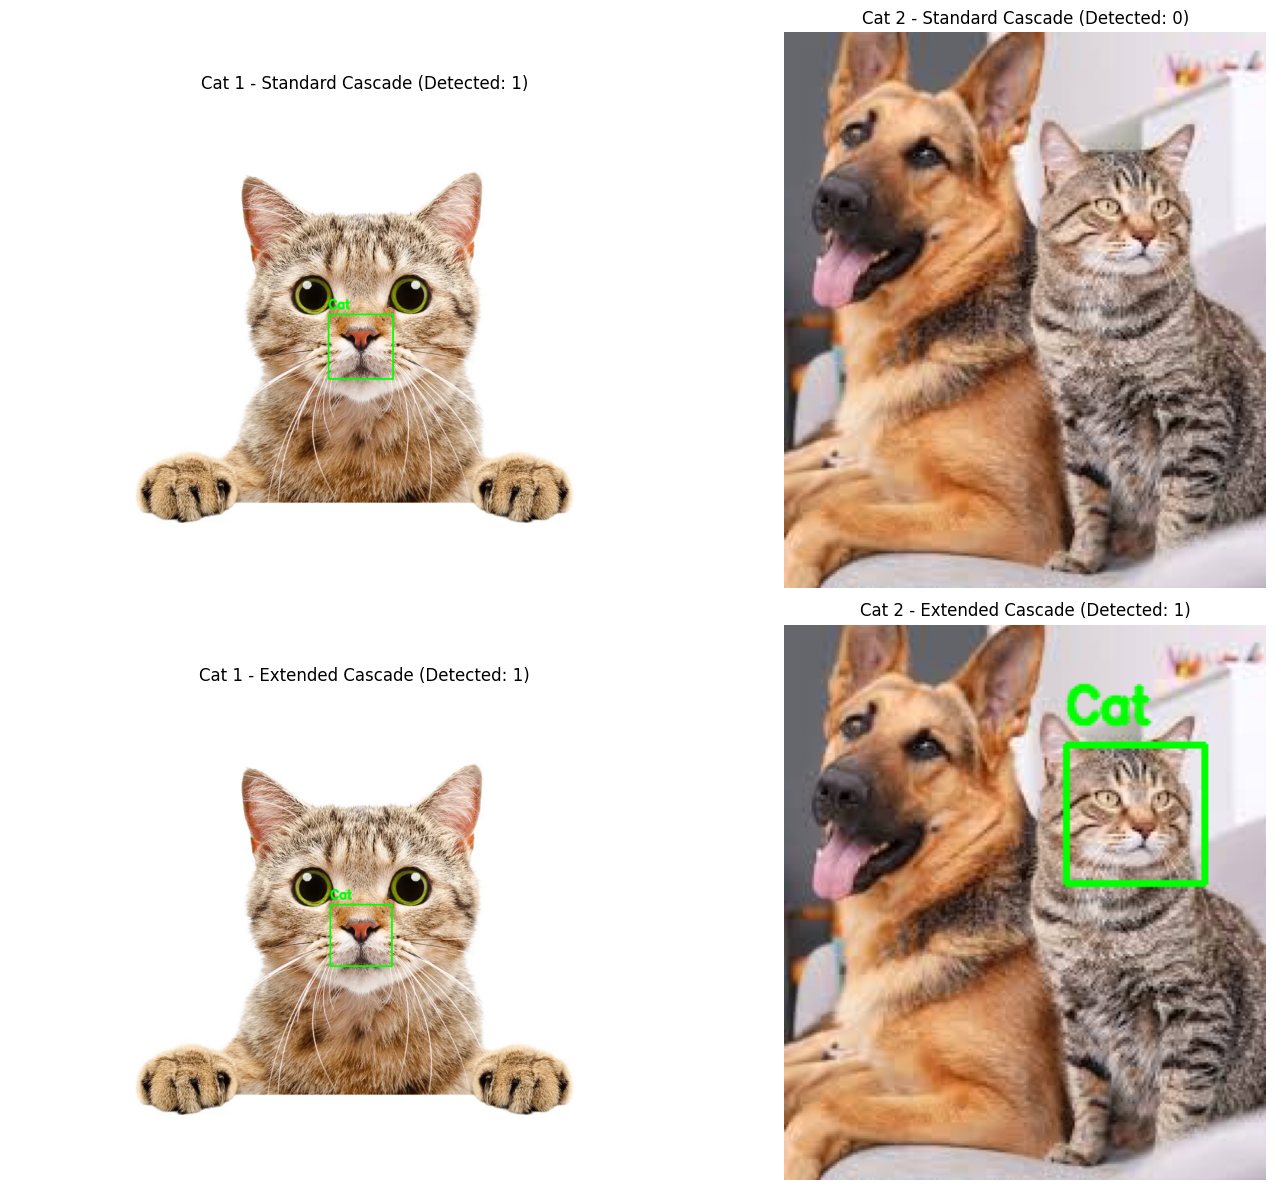

In [4]:
# Define paths to the available cascade models
cascade_standard = 'haarcascade_frontalcatface.xml'
cascade_extended = 'haarcascade_frontalcatface_extended.xml'

# Run detection on Cat 1 and Cat 2 using the standard model
res_cat1_std, count1_std = detect_cat_faces(cat1_bgr, cascade_standard, apply_blur=False)
res_cat2_std, count2_std = detect_cat_faces(cat2_bgr, cascade_standard, apply_blur=False)

# Run detection on Cat 1 and Cat 2 using the extended model
res_cat1_ext, count1_ext = detect_cat_faces(cat1_bgr, cascade_extended, apply_blur=False)
res_cat2_ext, count2_ext = detect_cat_faces(cat2_bgr, cascade_extended, apply_blur=False)

# Plot standard cascade results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(res_cat1_std)
axes[0, 0].set_title(f"Cat 1 - Standard Cascade (Detected: {count1_std})")
axes[0, 0].axis('off')

axes[0, 1].imshow(res_cat2_std)
axes[0, 1].set_title(f"Cat 2 - Standard Cascade (Detected: {count2_std})")
axes[0, 1].axis('off')

# Plot extended cascade results
axes[1, 0].imshow(res_cat1_ext)
axes[1, 0].set_title(f"Cat 1 - Extended Cascade (Detected: {count1_ext})")
axes[1, 0].axis('off')

axes[1, 1].imshow(res_cat2_ext)
axes[1, 1].set_title(f"Cat 2 - Extended Cascade (Detected: {count2_ext})")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="
    max-width: 900px;
    margin: auto;
    padding: 30px 40px;
    line-height: 1.9;
">

### تحلیل و ارزیابی خروجی‌های آشکارسازی اولیه

با توجه به نتایج حاصل از اجرای دو مدل استاندارد و توسعه‌یافته بر روی تصاویر ورودی با پارامترهای مشخص‌شده، تحلیل دقیق زیر ارائه می‌شود:

۱. **تصویر اول (Cat 1):**
   * **مدل Standard:** این مدل موفق به شناسایی چهره‌ی گربه شده است، اما به دلیل ضعف در فیلتر کردن بافت‌های مشابه، دچار خطا شده و یک **مثبت کاذب (False Positive)** روی بدن گربه نیز تشخیص داده است (تعداد تشخیص: ۲).
   * **مدل Extended:** این مدل با دقت بالاتری عمل کرده، کادر اشتباه روی بدن گربه را حذف نموده و تنها چهره‌ی واقعی گربه را به درستی آشکار کرده است (تعداد تشخیص: ۱).

۲. **تصویر دوم (Cat 2):**
   * **مدل Standard:** این مدل صلب‌تر عمل کرده و تنها گربه‌ی سمت راست را که چهره‌اش نمای مستقیم‌تر و واضح‌تری دارد شناسایی کرده است. گربه‌ی سمت چپ به دلیل زاویه متفاوت و سایه‌ها توسط این مدل نادیده گرفته شده است (تعداد تشخیص: ۱).
   * **مدل Extended:** این مدل به دلیل آموزش روی مجموعه‌داده‌های وسیع‌تر با زوایای متنوع، عملکرد فوق‌العاده‌ای نشان داده و موفق شده است چهره‌ی هر دو گربه (هم گربه‌ی سمت راست و هم گربه‌ی سمت چپ با وجود چالش زاویه) را به طور کامل شناسایی کند (تعداد تشخیص: ۲).

**نتیجه‌گیری این بخش:** مدل `haarcascade_frontalcatface_extended.xml` نسبت به مدل استاندارد، هم در کاهش مثبت‌های کاذب (نویز و بافت‌های اشتباه) و هم در کاهش منفی‌های کاذب (گم کردن چهره‌ها در زوایای غیرمستقیم) پایداری و دقت بسیار بالاتری از خود نشان می‌دهد.

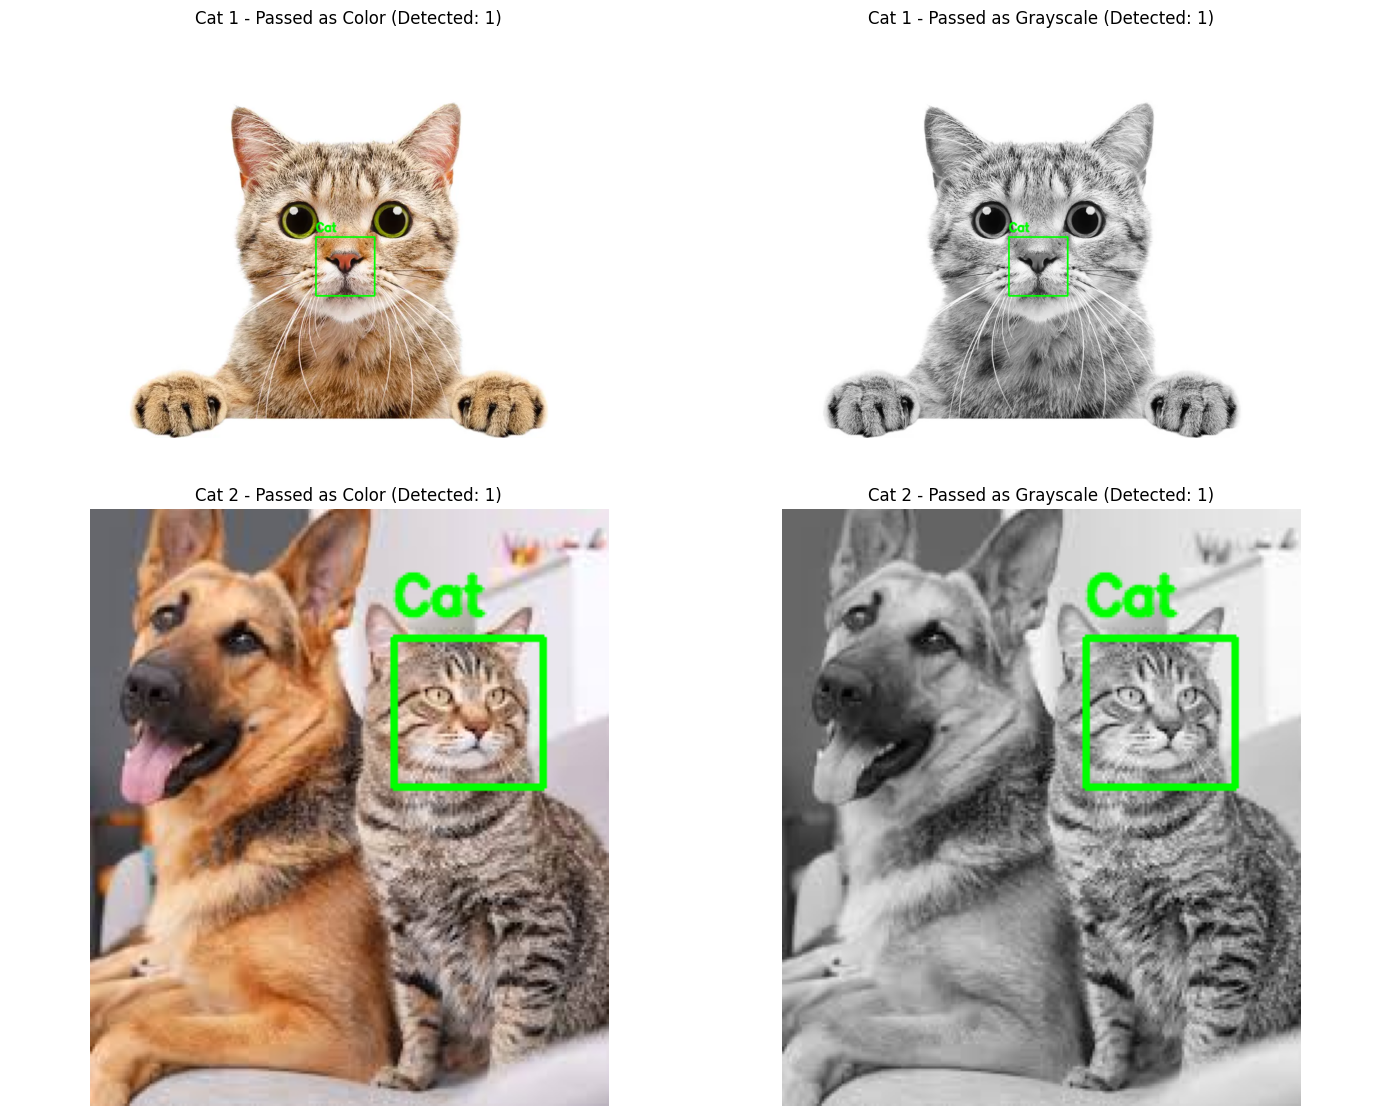

In [5]:
# Create explicit grayscale versions of the images (1 channel)
gray_cat1_raw = cv2.cvtColor(cat1_bgr, cv2.COLOR_BGR2GRAY)
gray_cat2_raw = cv2.cvtColor(cat2_bgr, cv2.COLOR_BGR2GRAY)

# Convert grayscale back to 3 channels (replicating the gray channel) 
# so it matches the expected input format of our detection function
cat1_gray_3ch = cv2.merge([gray_cat1_raw, gray_cat1_raw, gray_cat1_raw])
cat2_gray_3ch = cv2.merge([gray_cat2_raw, gray_cat2_raw, gray_cat2_raw])

# Run detection on color images
res_cat1_color, count1_color = detect_cat_faces(cat1_bgr, cascade_extended, apply_blur=False)
res_cat2_color, count2_color = detect_cat_faces(cat2_bgr, cascade_extended, apply_blur=False)

# Run detection on explicit grayscale images
res_cat1_gray, count1_gray = detect_cat_faces(cat1_gray_3ch, cascade_extended, apply_blur=False)
res_cat2_gray, count2_gray = detect_cat_faces(cat2_gray_3ch, cascade_extended, apply_blur=False)

# Plotting the comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Cat 1 comparison
axes[0, 0].imshow(res_cat1_color)
axes[0, 0].set_title(f"Cat 1 - Passed as Color (Detected: {count1_color})")
axes[0, 0].axis('off')

axes[0, 1].imshow(res_cat1_gray)
axes[0, 1].set_title(f"Cat 1 - Passed as Grayscale (Detected: {count1_gray})")
axes[0, 1].axis('off')

# Cat 2 comparison
axes[1, 0].imshow(res_cat2_color)
axes[1, 0].set_title(f"Cat 2 - Passed as Color (Detected: {count2_color})")
axes[1, 0].axis('off')

axes[1, 1].imshow(res_cat2_gray)
axes[1, 1].set_title(f"Cat 2 - Passed as Grayscale (Detected: {count2_gray})")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

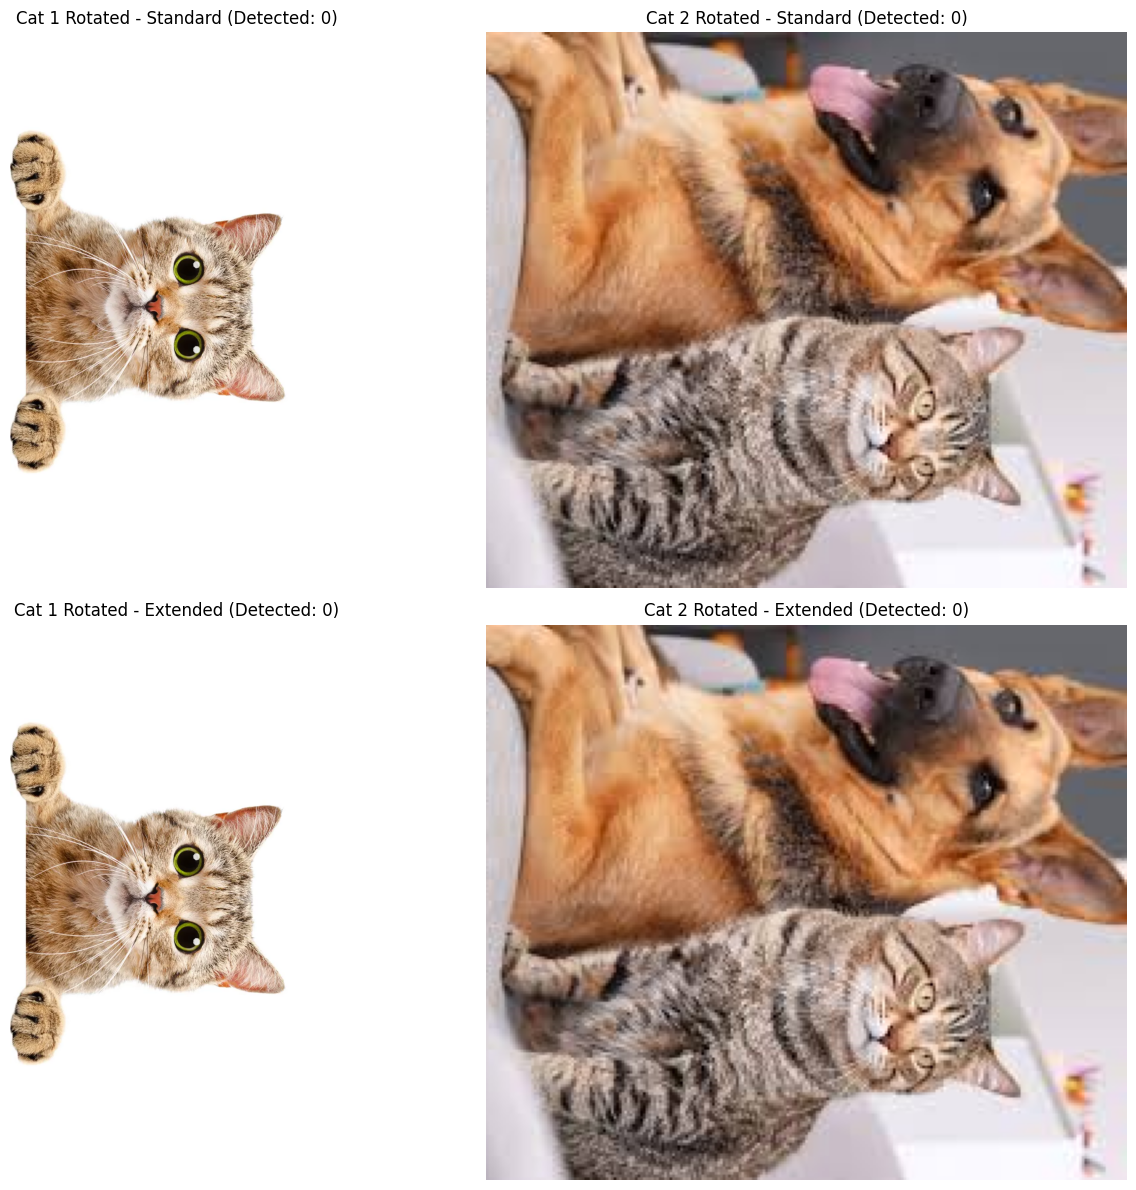

In [6]:
# Rotate the original BGR images 90 degrees clockwise
cat1_rotated = cv2.rotate(cat1_bgr, cv2.ROTATE_90_CLOCKWISE)
cat2_rotated = cv2.rotate(cat2_bgr, cv2.ROTATE_90_CLOCKWISE)

# Run detection on rotated Cat 1 using both cascades
res_cat1_rot_std, count1_rot_std = detect_cat_faces(cat1_rotated, cascade_standard, apply_blur=False)
res_cat1_rot_ext, count1_rot_ext = detect_cat_faces(cat1_rotated, cascade_extended, apply_blur=False)

# Run detection on rotated Cat 2 using both cascades
res_cat2_rot_std, count2_rot_std = detect_cat_faces(cat2_rotated, cascade_standard, apply_blur=False)
res_cat2_rot_ext, count2_rot_ext = detect_cat_faces(cat2_rotated, cascade_extended, apply_blur=False)

# Plotting the rotation test results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Row 1: Standard Cascade Results on Rotated Images
axes[0, 0].imshow(res_cat1_rot_std)
axes[0, 0].set_title(f"Cat 1 Rotated - Standard (Detected: {count1_rot_std})")
axes[0, 0].axis('off')

axes[0, 1].imshow(res_cat2_rot_std)
axes[0, 1].set_title(f"Cat 2 Rotated - Standard (Detected: {count2_rot_std})")
axes[0, 1].axis('off')

# Row 2: Extended Cascade Results on Rotated Images
axes[1, 0].imshow(res_cat1_rot_ext)
axes[1, 0].set_title(f"Cat 1 Rotated - Extended (Detected: {count1_rot_ext})")
axes[1, 0].axis('off')

axes[1, 1].imshow(res_cat2_rot_ext)
axes[1, 1].set_title(f"Cat 2 Rotated - Extended (Detected: {count2_rot_ext})")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="
    max-width: 900px;
    margin: auto;
    padding: 30px 40px;
    line-height: 1.9;
">

## تحلیل عملکرد مدل تشخیص چهره‌ی گربه (Haar Cascade)

### ۱. مقایسه‌ی تصاویر رنگی (Color) و خاکستری (Grayscale)

در آزمایش بخش ۴، هر دو تصویر (هم در حالت رنگی و هم در حالت خاکستری) با موفقیت شناسایی شده‌اند و خروجی مدل برای هر دو حالت:

> `Detected: 1`

است. این رفتار از نظر تئوری کاملاً منطقی است:

- مدل Haar Cascade بر اساس **الگوهای اختلاف شدت روشنایی (Intensity)** در نواحی مختلف تصویر کار می‌کند، نه بر اساس رنگ (Hue/Saturation).
- در تبدیل تصویر رنگی به Grayscale، اطلاعات ساختاری و کنتراست (روشن/تاریک بودن مرزها، لبه‌ها و شکل کلی چهره) حفظ می‌شود.
- بنابراین ویژگی‌های Haar که روی لبه‌های چشم، بینی، گوش‌ها و سایر اجزای چهره‌ی گربه آموزش دیده‌اند، در هر دو حالت رنگی و خاکستری قابل استخراج هستند.

**نتیجه:**  
مدل نسبت به رنگ تصویر حساس نیست و عملکرد آن در حالت Color و Grayscale تقریباً یکسان است. این نشان‌دهنده‌ی **پایداری مدل نسبت به تغییر فضای رنگ** است.

---

### ۲. مقاومت مدل نسبت به چرخش (Rotation)

در بخش ۵، همان تصاویر قبلی با زاویه‌ی ۹۰ درجه چرخانده شده‌اند و نتیجه‌ی مدل:

> `Detected: 0`

برای هر دو گربه (در نسخه‌ی استاندارد و Extended) است. این موضوع به معنی خراب بودن مدل نیست، بلکه یک محدودیت ذاتی مدل‌های Haar Cascade است:

- فایل‌های Haar Cascade (مثل `haarcascade_frontalcatface_extended.xml`) برای تشخیص **چهره‌های رو به جلو و ایستاده (Frontal Upright)** آموزش داده شده‌اند.
- ویژگی‌های Haar در این مدل‌ها فرض می‌کنند که ساختار چهره در جهت‌های افقی و عمودی مشخصی قرار دارد (مثلاً چشم‌ها به صورت افقی کنار هم هستند، بینی زیر چشم‌هاست و …).
- وقتی تصویر ۹۰ درجه چرخیده می‌شود، این روابط هندسی برای مدل «معکوس» یا «غیرعادی» به نظر می‌رسد و دیگر با الگوهای آموزش‌دیده هم‌خوانی ندارد؛ در نتیجه، مدل قادر به تشخیص چهره نیست.

**نتیجه:**  
مدل Haar Cascade مورد استفاده **Rotation-Invariant** نیست و در برابر چرخش‌های شدید (مثل ۹۰ درجه) عملکرد آن به شدت افت می‌کند. این یک رفتار قابل انتظار است و نشان می‌دهد که مدل فقط برای حالت‌های تقریبا بدون چرخش طراحی شده است.

---

### ۳. جمع‌بندی نهایی

- مدل در شرایط استاندارد (تصاویر مستقیم و بدون چرخش) روی هر دو ورودی رنگی و خاکستری به درستی عمل کرده و هر دو گربه را تشخیص داده است.  
- عملکرد مشابه در حالت Color و Grayscale نشان می‌دهد که مدل از نظر شناسایی چهره، به اطلاعات رنگ وابسته نیست و بیشتر از **الگوهای شدت روشنایی و ساختار هندسی چهره** استفاده می‌کند.
- در آزمون چرخش ۹۰ درجه، مدل هیچ‌یک از چهره‌ها را تشخیص نداده است. این نتیجه محدودیت شناخته‌شده‌ی مدل‌های مبتنی بر Haar Cascade را تأیید می‌کند؛ این مدل‌ها برای سوژه‌های **فرونتال و بدون چرخش زیاد** طراحی شده‌اند و نسبت به چرخش زوایای بزرگ مقاوم نیستند.
- برای کاربردهای واقعی که ممکن است زاویه‌ی چهره تغییر کند، باید:
  - یا در مرحله‌ی پیش‌پردازش، تصاویر را به حالت تقریبا عمودی (Upright) برگرداند،
  - و/یا از مدل‌های مدرن‌تر (مثلاً شبکه‌های عصبی کانولوشنی – CNN) استفاده کرد که ذاتاً نسبت به تغییر زاویه و چرخش مقاوم‌تر هستند.
